In [1]:

%pip install -q geopandas pandas matplotlib folium shapely contextily scikit-learn

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
import contextily as ctx

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries loaded successfully.")
print("GeoPandas version:", gpd.__version__)

import sklearn
print("scikit-learn version:", sklearn.__version__)


Note: you may need to restart the kernel to use updated packages.
Libraries loaded successfully.
GeoPandas version: 1.2.0
scikit-learn version: 1.9.1


In [2]:

# USGS Earthquake Catalog: year 2025, magnitude >= 3, Iran bounding box
usgs_url = (
    "https://earthquake.usgs.gov/fdsnws/event/1/query?"
    "format=csv&"
    "starttime=2025-01-01&"
    "endtime=2025-12-31&"
    "minlatitude=25&"
    "maxlatitude=40.5&"
    "minlongitude=44&"
    "maxlongitude=63.5&"
    "minmagnitude=3"
)

countries_url = (
    "https://raw.githubusercontent.com/"
    "nvkelso/natural-earth-vector/master/"
    "geojson/ne_110m_admin_0_countries.geojson"
)

# Read earthquake CSV
raw_df = pd.read_csv(usgs_url)
raw_df["time"] = pd.to_datetime(raw_df["time"], errors="coerce")

# Convert to GeoDataFrame
earthquakes_raw = gpd.GeoDataFrame(
    raw_df,
    geometry=gpd.points_from_xy(raw_df["longitude"], raw_df["latitude"]),
    crs="EPSG:4326"
)

# Read Natural Earth countries and select Iran
countries = gpd.read_file(countries_url)
iran = countries[
    (countries["ADMIN"] == "Iran") | (countries["ADM0_A3"] == "IRN")
].copy()

if iran.empty:
    raise ValueError("Iran boundary was not found in the Natural Earth dataset.")

print("Earthquake records downloaded:", len(earthquakes_raw))
print("Iran boundary loaded:", len(iran) >= 1)


Earthquake records downloaded: 203
Iran boundary loaded: True


First five records:


,time,latitude,longitude,depth,mag,place,geometry
0,2025-12-24 06:48:35.910000+00:00,27.0016,54.9871,10.0,4.3,"50 km NNE of Bandar-e Lengeh, Iran",POINT (54.9871 27.0016)
1,2025-12-23 22:43:05.739000+00:00,28.2952,51.6921,10.0,4.1,"105 km SW of Fīrūzābād, Iran",POINT (51.6921 28.2952)
2,2025-12-22 23:52:18.662000+00:00,28.6714,51.0691,10.0,4.0,"40 km SE of Bushehr, Iran",POINT (51.0691 28.6714)
3,2025-12-22 13:13:51.290000+00:00,26.8602,55.0341,10.0,4.2,"36 km NNE of Bandar-e Lengeh, Iran",POINT (55.0341 26.8602)
4,2025-12-19 13:38:52.420000+00:00,27.2631,53.8535,10.0,4.4,"52 km SSW of Gerāsh, Iran",POINT (53.8535 27.2631)



Shape: (203, 23)
CRS: EPSG:4326

Magnitude statistics:


count    203.000000
mean       4.333498
std        0.293934
min        3.900000
25%        4.100000
50%        4.300000
75%        4.500000
max        5.600000
Name: mag, dtype: float64

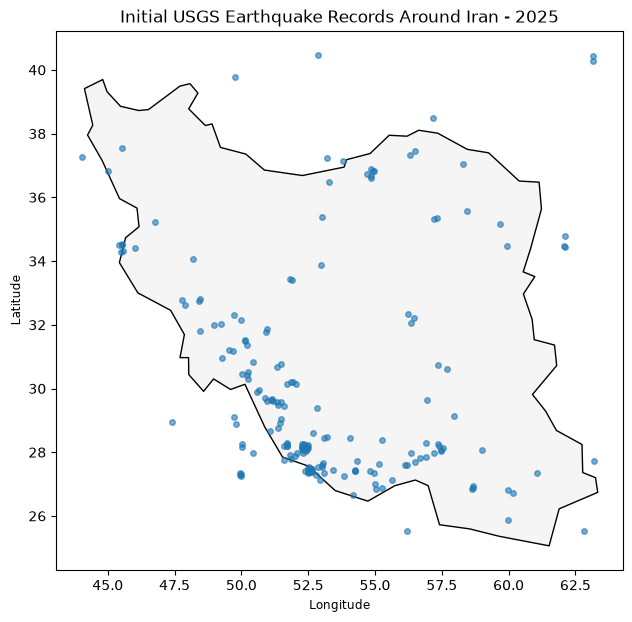

In [3]:

print("First five records:")
display(
    earthquakes_raw[
        ["time", "latitude", "longitude", "depth", "mag", "place", "geometry"]
    ].head()
)

print("\nShape:", earthquakes_raw.shape)
print("CRS:", earthquakes_raw.crs)

print("\nMagnitude statistics:")
display(earthquakes_raw["mag"].describe())

ax = iran.plot(figsize=(9, 7), facecolor="whitesmoke", edgecolor="black")
earthquakes_raw.plot(ax=ax, markersize=16, alpha=0.60)
plt.title("Initial USGS Earthquake Records Around Iran - 2025")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


In [4]:

# Merge Iran polygons if needed
iran_geometry = iran.geometry.union_all()

# Keep only events strictly inside Iran
earthquakes = earthquakes_raw[
    earthquakes_raw.geometry.within(iran_geometry)
].copy()

earthquakes.reset_index(drop=True, inplace=True)

# Stronger events
strong_eq = earthquakes[earthquakes["mag"] >= 4.5].copy()

# Metric CRS centered approximately on Iran
iran_metric_crs = (
    "+proj=aeqd +lat_0=32 +lon_0=53 "
    "+datum=WGS84 +units=m +no_defs"
)

if len(strong_eq) > 0:
    strong_metric = strong_eq.to_crs(iran_metric_crs)
    buffers_metric = strong_metric.copy()
    buffers_metric["geometry"] = strong_metric.geometry.buffer(100_000)
    buffers = buffers_metric.to_crs("EPSG:4326")
else:
    buffers = strong_eq.copy()

print("Earthquakes inside Iran:", len(earthquakes))
print("Earthquakes with M >= 4.5:", len(strong_eq))
print("100-km buffers created:", len(buffers))


Earthquakes inside Iran: 156
Earthquakes with M >= 4.5: 48
100-km buffers created: 48


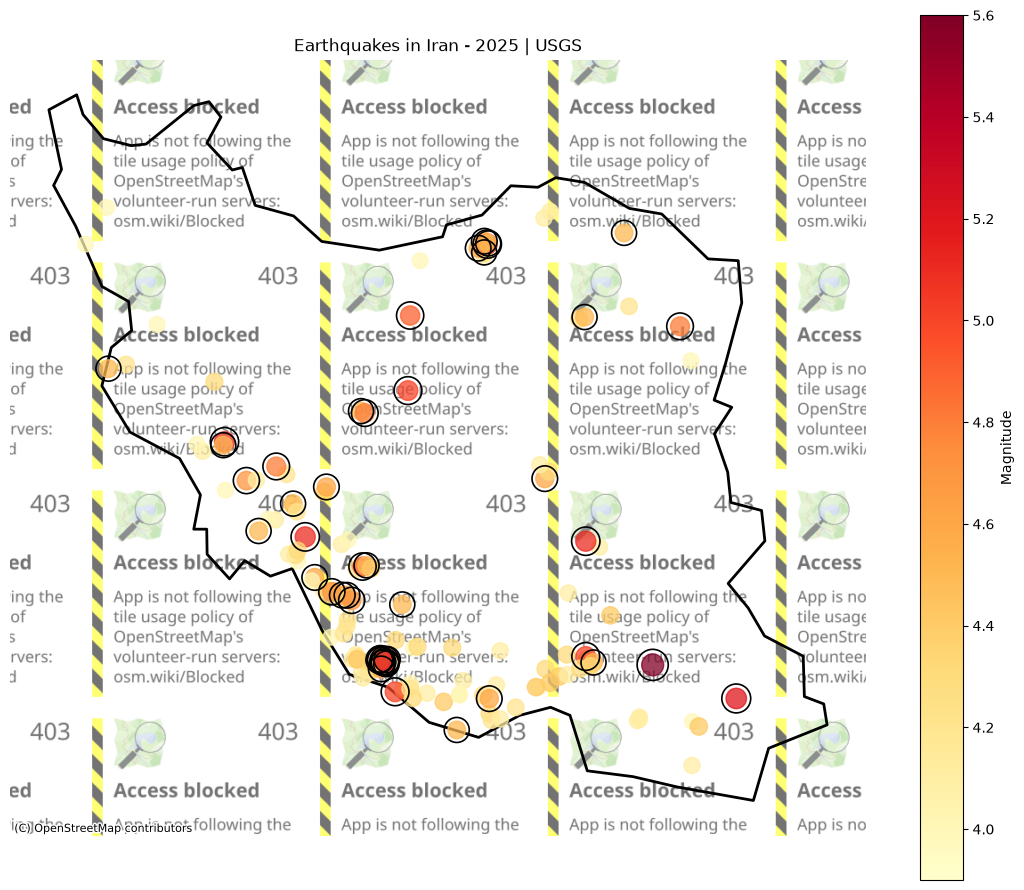

In [5]:

iran_3857 = iran.to_crs(epsg=3857)
eq_3857 = earthquakes.to_crs(epsg=3857)
strong_3857 = strong_eq.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 9))

iran_3857.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=2
)

eq_3857.plot(
    ax=ax,
    column="mag",
    cmap="YlOrRd",
    markersize=eq_3857["mag"] ** 2 * 8,
    alpha=0.75,
    legend=True,
    legend_kwds={"label": "Magnitude"}
)

if len(strong_3857) > 0:
    strong_3857.plot(
        ax=ax,
        facecolor="none",
        edgecolor="black",
        markersize=strong_3857["mag"] ** 2 * 16,
        linewidth=1.2
    )

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik,
        alpha=0.55
    )
except Exception as e:
    print("Basemap could not be downloaded; GIS layers are still shown.")

ax.set_title("Earthquakes in Iran - 2025 | USGS")
ax.set_axis_off()
plt.tight_layout()
plt.show()



## سلول 6 — آماده‌سازی داده برای مدل هوش مصنوعی

مدل K-Means یک الگوریتم **یادگیری بدون‌ناظر** است. یعنی برچسب از پیش تعیین‌شده ندارد و خودش نمونه‌های مشابه را در چند گروه قرار می‌دهد.

ویژگی‌های مورد استفاده:

- `latitude`: موقعیت شمالی/جنوبی
- `longitude`: موقعیت شرقی/غربی
- `mag`: بزرگی زلزله
- `depth`: عمق زلزله

چون مقیاس این ویژگی‌ها متفاوت است، قبل از آموزش با `StandardScaler` استانداردسازی می‌شوند.

**خروجی مورد انتظار:** پنج ردیف اول ویژگی‌های ورودی و ابعاد ماتریس مدل نمایش داده می‌شود.


In [6]:

if len(earthquakes) < 4:
    raise ValueError("Not enough earthquake records for K-Means clustering.")

ml_data = earthquakes[["latitude", "longitude", "mag", "depth"]].copy()

# Fill missing values defensively
for col in ml_data.columns:
    if ml_data[col].isna().any():
        ml_data[col] = ml_data[col].fillna(ml_data[col].median())

features = ["latitude", "longitude", "mag", "depth"]
X = ml_data[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features used by the model:")
display(X.head())
print("Model matrix shape:", X_scaled.shape)


Features used by the model:


,latitude,longitude,mag,depth
0,27.0016,54.9871,4.3,10.0
1,28.2952,51.6921,4.1,10.0
2,28.6714,51.0691,4.0,10.0
3,26.8602,55.0341,4.2,10.0
4,27.2631,53.8535,4.4,10.0


Model matrix shape: (156, 4)


In [7]:

# Four clusters are simple enough for a beginner GIS/ML project
n_clusters = 4

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)
earthquakes["cluster"] = cluster_labels

# Evaluate clustering
sil_score = silhouette_score(X_scaled, cluster_labels)

print(f"Silhouette Score: {sil_score:.3f}")
print("\nNumber of earthquakes in each cluster:")
display(earthquakes["cluster"].value_counts().sort_index().rename("count"))

cluster_summary = (
    earthquakes
    .groupby("cluster")[["latitude", "longitude", "mag", "depth"]]
    .agg(["count", "mean"])
    .round(2)
)

print("\nCluster summary:")
display(cluster_summary)


Silhouette Score: 0.300

Number of earthquakes in each cluster:


cluster
0    71
1    63
2    21
3     1
Name: count, dtype: int64


Cluster summary:


latitude        longitude          mag       depth       
           count   mean     count   mean count  mean count   mean
cluster                                                          
0             71  27.85        71  54.63    71  4.22    71  10.73
1             63  30.73        63  50.47    63  4.42    63  10.13
2             21  35.30        21  56.12    21  4.47    21  10.00
3              1  28.07         1  59.01     1  5.60     1  76.74

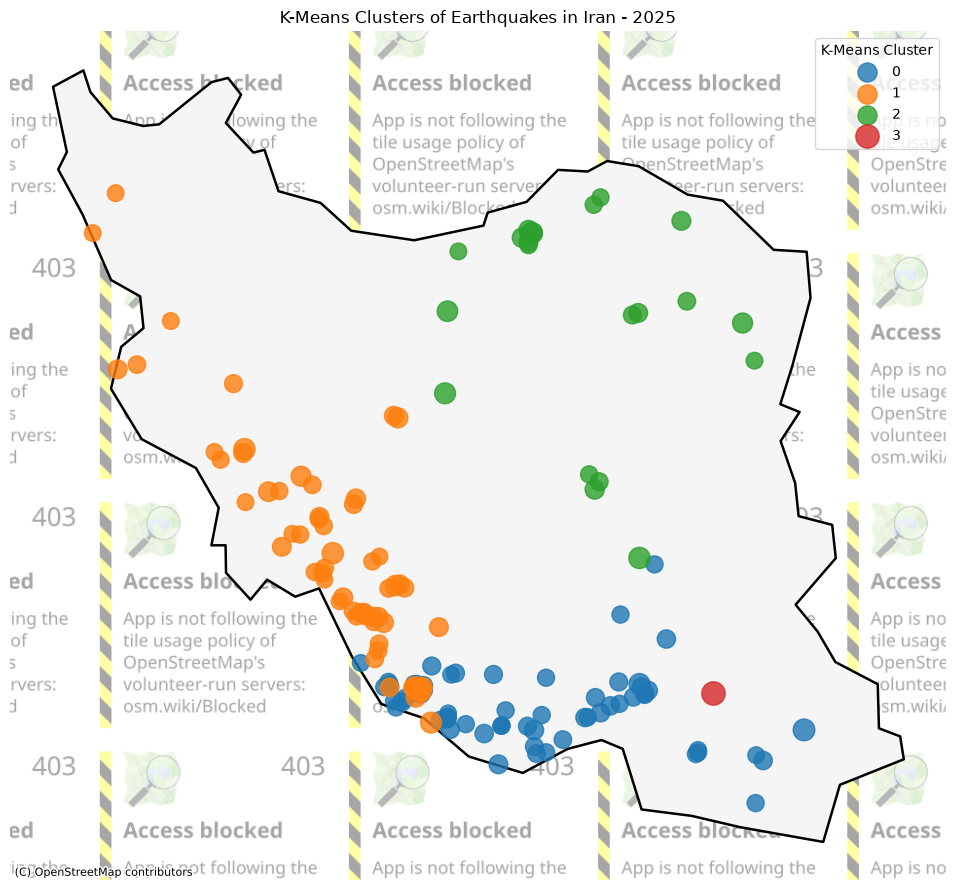

In [8]:

clustered_3857 = earthquakes.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(11, 9))
iran_3857.plot(ax=ax, facecolor="whitesmoke", edgecolor="black", linewidth=1.8)

clustered_3857.plot(
    ax=ax,
    column="cluster",
    categorical=True,
    cmap="tab10",
    markersize=clustered_3857["mag"] ** 2 * 9,
    alpha=0.80,
    legend=True,
    legend_kwds={"title": "K-Means Cluster"}
)

try:
    ctx.add_basemap(
        ax,
        source=ctx.providers.OpenStreetMap.Mapnik,
        alpha=0.35
    )
except Exception:
    pass

ax.set_title("K-Means Clusters of Earthquakes in Iran - 2025")
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [10]:

cluster_colors = {
    0: "blue",
    1: "red",
    2: "green",
    3: "purple"
}

m = folium.Map(
    location=[32.5, 53.5],
    zoom_start=5,
    tiles="OpenStreetMap"
)

folium.GeoJson(
    iran.__geo_interface__,
    name="Iran Boundary",
    style_function=lambda feature: {
        "fillColor": "transparent",
        "color": "black",
        "weight": 2
    }
).add_to(m)

if len(buffers) > 0:
    folium.GeoJson(
        buffers[["geometry"]].__geo_interface__,
        name="100 km Buffer around M >= 4.5",
        style_function=lambda feature: {
            "fillColor": "#ff7800",
            "color": "#ff7800",
            "weight": 1,
            "fillOpacity": 0.10
        }
    ).add_to(m)

for _, row in earthquakes.iterrows():
    cluster_id = int(row["cluster"])
    color = cluster_colors.get(cluster_id, "gray")

    popup_text = f"""
    <b>Magnitude:</b> {row['mag']:.1f}<br>
    <b>Depth:</b> {row['depth']:.1f} km<br>
    <b>Date:</b> {row['time']}<br>
    <b>Location:</b> {row['place']}<br>
    <b>K-Means Cluster:</b> {cluster_id}
    """

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=max(4, float(row["mag"]) * 1.7),
        popup=folium.Popup(popup_text, max_width=350),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.72,
        weight=1
    ).add_to(m)

folium.LayerControl().add_to(m)

map_filename = "iran_earthquake_kmeans_map.html"
m.save(map_filename)
print("Interactive map saved as:", map_filename)



Interactive map saved as: iran_earthquake_kmeans_map.html



## سلول 10 — نتیجه‌گیری، تفسیر و خروجی فایل

در سلول آخر خلاصه‌ای از داده و مدل چاپ و نسخه CSV شامل برچسب Cluster ذخیره می‌شود.

**نحوه تفسیر مدل:**

K-Means داده‌ها را بر اساس شباهت هم‌زمان در موقعیت مکانی، بزرگی و عمق تقسیم می‌کند. بنابراین Clusterها لزوماً معادل گسل‌ها یا نواحی تکتونیکی رسمی نیستند؛ بلکه الگوهای آماری موجود در همین داده‌اند.

**خروجی مورد انتظار:** مشخصات شدیدترین زلزله، Silhouette Score، خلاصه خوشه‌ها و نام فایل CSV خروجی نمایش داده می‌شود.


In [11]:

if len(earthquakes) > 0:
    largest = earthquakes.loc[earthquakes["mag"].idxmax()]

    print("=" * 65)
    print("GIS + MACHINE LEARNING ANALYSIS | IRAN EARTHQUAKES 2025")
    print("=" * 65)
    print(f"Earthquakes inside Iran: {len(earthquakes)}")
    print(f"Mean magnitude: {earthquakes['mag'].mean():.2f}")
    print(f"Median magnitude: {earthquakes['mag'].median():.2f}")
    print(f"M >= 4.5 events: {len(strong_eq)}")
    print(f"K-Means clusters: {n_clusters}")
    print(f"Silhouette Score: {sil_score:.3f}")

    print("\nLargest recorded event in this dataset")
    print("-" * 40)
    print(f"Magnitude: {largest['mag']:.1f}")
    print(f"Depth: {largest['depth']:.1f} km")
    print(f"Location: {largest['place']}")
    print(f"Date: {largest['time']}")
    print(f"Cluster: {int(largest['cluster'])}")

    output_columns = [
        "time", "latitude", "longitude", "depth", "mag", "place", "cluster"
    ]
    output_filename = "iran_earthquakes_2025_with_kmeans_clusters.csv"
    earthquakes[output_columns].to_csv(output_filename, index=False)

    print("\nOutput CSV saved as:", output_filename)
    print("Interactive HTML map:", map_filename)

    print("\nInterpretation:")
    print(
        "K-Means found groups of earthquake records that are similar in "
        "location, magnitude, and depth. These clusters are exploratory "
        "patterns and should not be interpreted as earthquake predictions."
    )


GIS + MACHINE LEARNING ANALYSIS | IRAN EARTHQUAKES 2025
Earthquakes inside Iran: 156
Mean magnitude: 4.34
Median magnitude: 4.30
M >= 4.5 events: 48
K-Means clusters: 4
Silhouette Score: 0.300

Largest recorded event in this dataset
----------------------------------------
Magnitude: 5.6
Depth: 76.7 km
Location: 131 km SSE of Bam, Iran
Date: 2025-08-05 05:06:47.092000+00:00
Cluster: 3

Output CSV saved as: iran_earthquakes_2025_with_kmeans_clusters.csv
Interactive HTML map: iran_earthquake_kmeans_map.html

Interpretation:
K-Means found groups of earthquake records that are similar in location, magnitude, and depth. These clusters are exploratory patterns and should not be interpreted as earthquake predictions.



# تمرین‌های پیشنهادی برای توسعه پروژه

1. **تعداد Clusterها را تغییر دهید:** مقدار `n_clusters` را از 2 تا 8 امتحان کنید و Silhouette Score را مقایسه کنید.
2. **فقط داده‌های مکانی را استفاده کنید:** مدل را فقط با `latitude` و `longitude` آموزش دهید و نتیجه را با مدل چهارویژگی مقایسه کنید.
3. **تحلیل ماهانه:** ستون ماه را از `time` استخراج و تعداد زلزله‌ها را در هر ماه رسم کنید.
4. **مرز استان‌ها را اضافه کنید:** با Spatial Join مشخص کنید هر استان چند زلزله داشته و سپس آن را با خوشه‌های K-Means مقایسه کنید.
5. **مدل DBSCAN را امتحان کنید:** به عنوان الگوریتم خوشه‌بندی مکانی جایگزین، DBSCAN را اجرا و نقاط Noise را بررسی کنید.

## نتیجه کلی

این Notebook یک Workflow کامل و کوچک شامل **داده واقعی → GIS → تحلیل مکانی → یادگیری ماشین → ارزیابی → نقشه ثابت → نقشه تعاملی** ارائه می‌دهد و برای ارائه کلاسی یا پروژه مقدماتی مناسب است.
